# Product Demand Forecasting Using Ridge and Lasso Regression

**Dataset:** `Retail_Dataset.csv` — historical product order demand across warehouses, categories, and time.


---
## Problem Definition

**In this project:** Predict `Order_Demand` for a product on a given day using features such as warehouse, product category, promotions, holidays, and petrol price — so that retailers can anticipate demand and optimize inventory and procurement decisions. Since the target is a continuous numeric quantity, this is a **regression problem**. We specifically use **Ridge and Lasso Regression** to handle the multicollinearity introduced by one-hot encoding many categorical features (warehouses, product categories), and to compare an L2 vs L1 regularization approach on this data.


---
## Data Collection

**In this project:** `Retail_Dataset.csv` — 169,211 records of daily product order demand, pulled together with warehouse, product category, promotion, holiday, and petrol price information.


### Mount Google Drive and load the dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/ML-Project/Retail_Dataset.csv')


### Additional imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)


---
## Data Understanding

**What it means:** Look at data types, value ranges, and how each feature relates to the outcome before touching any model.

**In this project:** Check the shape, column types, and value ranges of the dataset — `Order_Demand` turns out to be heavily right-skewed, `Petrol_price` ranges 80-96, and there are 4 warehouses and 30 product categories to account for.


### Shape and first look

In [4]:
print("Shape:", df.shape)
df.head()


Shape: (169211, 11)


,Product_id,Product_Code,Warehouse,Product_Category,Date,Order_Demand,Open,Promo,StateHoliday,SchoolHoliday,Petrol_price
0,786725,Product_0033,Whse_S,Category_005,01/03/2016,16000,1,0,0,0,91
1,786743,Product_1825,Whse_S,Category_006,01/03/2016,50000,1,0,0,0,85
2,786967,Product_0551,Whse_S,Category_030,01/03/2016,3000,1,0,0,0,85
3,786856,Product_0556,Whse_S,Category_030,01/03/2016,1000,1,0,0,0,93
4,899538,Product_1844,Whse_A,Category_018,01/03/2016,7,1,0,0,0,95


### Data types and structure

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169211 entries, 0 to 169210
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Product_id        169211 non-null  int64 
 1   Product_Code      169211 non-null  object
 2   Warehouse         169211 non-null  object
 3   Product_Category  169211 non-null  object
 4   Date              169211 non-null  object
 5   Order_Demand      169211 non-null  int64 
 6   Open              169211 non-null  int64 
 7   Promo             169211 non-null  int64 
 8   StateHoliday      169211 non-null  object
 9   SchoolHoliday     169211 non-null  int64 
 10  Petrol_price      169211 non-null  int64 
dtypes: int64(6), object(5)
memory usage: 14.2+ MB


### Summary statistics

In [6]:
df.describe(include="all")


,Product_id,Product_Code,Warehouse,Product_Category,Date,Order_Demand,Open,Promo,StateHoliday,SchoolHoliday,Petrol_price
count,1.692110e+05,169211,169211,169211,169211,1.692110e+05,169211.000000,169211.000000,169211,169211.000000,169211.000000
unique,NaN,2117,4,30,289,NaN,NaN,NaN,3,NaN,NaN
top,NaN,Product_1359,Whse_J,Category_019,10/03/2016,NaN,NaN,NaN,0,NaN,NaN
freq,NaN,2607,131102,76640,1178,NaN,NaN,NaN,161447,NaN,NaN
mean,9.528887e+05,NaN,NaN,NaN,NaN,5.248118e+03,0.817742,0.395364,NaN,0.133401,87.986183
std,5.555751e+04,NaN,NaN,NaN,NaN,3.116296e+04,0.386058,0.488930,NaN,0.340009,4.909978
min,6.909430e+05,NaN,NaN,NaN,NaN,0.000000e+00,0.000000,0.000000,NaN,0.000000,80.000000
25%,9.054275e+05,NaN,NaN,NaN,NaN,2.000000e+01,1.000000,0.000000,NaN,0.000000,84.000000
50%,9.526430e+05,NaN,NaN,NaN,NaN,3.000000e+02,1.000000,0.000000,NaN,0.000000,88.000000
75%,1.001416e+06,NaN,NaN,NaN,NaN,2.000000e+03,1.000000,1.000000,NaN,0.000000,92.000000


### Categorical feature overview

In [7]:
for col in ["Warehouse", "Product_Category", "StateHoliday"]:
    print(f"{col}: {df[col].nunique()} unique values -> {sorted(df[col].unique())[:10]}")


Warehouse: 4 unique values -> ['Whse_A', 'Whse_C', 'Whse_J', 'Whse_S']
Product_Category: 30 unique values -> ['Category_001', 'Category_003', 'Category_005', 'Category_006', 'Category_007', 'Category_008', 'Category_009', 'Category_010', 'Category_011', 'Category_012']
StateHoliday: 3 unique values -> ['0', 'a', 'b']


---
## Data Cleaning & Preprocessing

**What it means:** Fix messy data — missing values, duplicates, wrong formats — and convert everything into a model-ready numeric form.

**In this project:** Parse the `Date` column, check for missing values and duplicate records, treat extreme outliers in `Order_Demand`, encode categorical columns, and scale numeric features.


### Check for missing values

No missing values were found in this dataset — a good sign, but we check explicitly rather than assuming it.

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct.round(2)})


,Missing Count,Missing %
Product_id,0,0.0
Product_Code,0,0.0
Warehouse,0,0.0
Product_Category,0,0.0
Date,0,0.0
Order_Demand,0,0.0
Open,0,0.0
Promo,0,0.0
StateHoliday,0,0.0
SchoolHoliday,0,0.0


### Check for duplicate records

We check both full-row duplicates and duplicate (Product, Date) combinations — the latter would mean the same product was recorded twice for the same day, which shouldn't happen.

In [9]:
print("Full duplicate rows:", df.duplicated().sum())
print("Duplicate (Product_id, Date) pairs:", df.duplicated(subset=["Product_id", "Date"]).sum())


Full duplicate rows: 0
Duplicate (Product_id, Date) pairs: 0


### Fix data formats — parsing the Date column

`Date` is currently stored as text. Checking a few values (e.g. `1/13/2016`) confirms the format is `M/D/YYYY`, not `D/M/YYYY` — day-first parsing would have silently failed or misparsed dates. We convert it to an actual datetime type and extract `Year`, `Month`, `Day`, and `DayOfWeek` as separate numeric features — these are useful predictors for demand (e.g. weekday vs weekend patterns, seasonality by month).

In [10]:
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek  # 0 = Monday, 6 = Sunday

df[["Date", "Year", "Month", "Day", "DayOfWeek"]].head()


,Date,Year,Month,Day,DayOfWeek
0,2016-01-03,2016,1,3,6
1,2016-01-03,2016,1,3,6
2,2016-01-03,2016,1,3,6
3,2016-01-03,2016,1,3,6
4,2016-01-03,2016,1,3,6


### Handling outliers in `Order_Demand`

`Order_Demand` is heavily right-skewed — most orders are small, but a few are extremely large (bulk orders).

In [11]:
print(df["Order_Demand"].describe())
print()
print("99th percentile:", df["Order_Demand"].quantile(0.99))
print("99.9th percentile:", df["Order_Demand"].quantile(0.999))
print("Maximum value:", df["Order_Demand"].max())


count    1.692110e+05
mean     5.248118e+03
std      3.116296e+04
min      0.000000e+00
25%      2.000000e+01
50%      3.000000e+02
75%      2.000000e+03
max      2.500000e+06
Name: Order_Demand, dtype: float64

99th percentile: 80000.0
99.9th percentile: 400000.0
Maximum value: 2500000


A handful of extreme bulk orders (up to 2.5 million units) sit far beyond the 99th percentile (~80,000). Left untreated, these would dominate the loss function during regression training and distort the model's coefficients.

We apply **Winsorization** (capping) at the 99th percentile rather than deleting these rows — the orders themselves are real, we just don't want a handful of records to dominate model training. The original column is kept for reference; the capped version is used going forward.

In [12]:
cap_value = df["Order_Demand"].quantile(0.99)
df["Order_Demand_Capped"] = np.where(df["Order_Demand"] > cap_value, cap_value, df["Order_Demand"])

print(f"Capped {(df['Order_Demand'] > cap_value).sum()} extreme values at {cap_value:,.0f}")
print()
print(df[["Order_Demand", "Order_Demand_Capped"]].describe())


Capped 1672 extreme values at 80,000

       Order_Demand  Order_Demand_Capped
count  1.692110e+05        169211.000000
mean   5.248118e+03          4028.095289
std    3.116296e+04         11362.293079
min    0.000000e+00             0.000000
25%    2.000000e+01            20.000000
50%    3.000000e+02           300.000000
75%    2.000000e+03          2000.000000
max    2.500000e+06         80000.000000


### Encoding categorical variables

- `Warehouse` (4 categories) and `StateHoliday` (3 categories) → **one-hot encoded**, since they have no natural order and low cardinality
- `Product_Category` (30 categories) → also one-hot encoded — still manageable and keeps category identity for the model
- `Product_Code` and `Product_id` are high-cardinality identifiers (2,117 unique products). They aren't encoded here — they'll be handled in **Feature Engineering (Step 6)**, where we decide whether to derive useful features from them or drop them.

In [13]:
categorical_cols = ["Warehouse", "StateHoliday", "Product_Category"]

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("Shape before encoding:", df.shape)
print("Shape after encoding :", df_encoded.shape)
df_encoded.head()


Shape before encoding: (169211, 16)
Shape after encoding : (169211, 47)


,Product_id,Product_Code,Date,Order_Demand,Open,Promo,SchoolHoliday,Petrol_price,Year,Month,Day,DayOfWeek,Order_Demand_Capped,Warehouse_Whse_C,Warehouse_Whse_J,Warehouse_Whse_S,StateHoliday_a,StateHoliday_b,Product_Category_Category_003,Product_Category_Category_005,Product_Category_Category_006,Product_Category_Category_007,Product_Category_Category_008,Product_Category_Category_009,Product_Category_Category_010,Product_Category_Category_011,Product_Category_Category_012,Product_Category_Category_013,Product_Category_Category_014,Product_Category_Category_015,Product_Category_Category_016,Product_Category_Category_017,Product_Category_Category_018,Product_Category_Category_019,Product_Category_Category_020,Product_Category_Category_021,Product_Category_Category_022,Product_Category_Category_023,Product_Category_Category_024,Product_Category_Category_026,Product_Category_Category_027,Product_Category_Category_028,Product_Category_Category_029,Product_Category_Category_030,Product_Category_Category_031,Product_Category_Category_032,Product_Category_Category_033
0,786725,Product_0033,2016-01-03,16000,1,0,0,91,2016,1,3,6,16000.0,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,786743,Product_1825,2016-01-03,50000,1,0,0,85,2016,1,3,6,50000.0,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,786967,Product_0551,2016-01-03,3000,1,0,0,85,2016,1,3,6,3000.0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,786856,Product_0556,2016-01-03,1000,1,0,0,93,2016,1,3,6,1000.0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
4,899538,Product_1844,2016-01-03,7,1,0,0,95,2016,1,3,6,7.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False


### Feature scaling

`Petrol_price` is on a very different numeric scale than binary flags like `Promo` or `Open`. We standardize it (mean 0, std 1) using `StandardScaler` — this matters for Ridge and Lasso specifically, since both penalize coefficient magnitude, and unscaled features would be penalized unfairly compared to scaled ones.

Note: `Order_Demand_Capped` (our target) is **not** scaled — we want predictions in real, interpretable units.

In [14]:
scaler = StandardScaler()
df_encoded["Petrol_price_scaled"] = scaler.fit_transform(df_encoded[["Petrol_price"]])

df_encoded[["Petrol_price", "Petrol_price_scaled"]].describe()


,Petrol_price,Petrol_price_scaled
count,169211.000000,1.692110e+05
mean,87.986183,-3.088896e-16
std,4.909978,1.000003e+00
min,80.000000,-1.626526e+00
25%,84.000000,-8.118559e-01
50%,88.000000,2.814088e-03
75%,92.000000,8.174840e-01
max,96.000000,1.632154e+00


### Cleaned dataset overview

In [15]:
print("Final cleaned shape:", df_encoded.shape)
df_encoded.head()


Final cleaned shape: (169211, 48)


,Product_id,Product_Code,Date,Order_Demand,Open,Promo,SchoolHoliday,Petrol_price,Year,Month,Day,DayOfWeek,Order_Demand_Capped,Warehouse_Whse_C,Warehouse_Whse_J,Warehouse_Whse_S,StateHoliday_a,StateHoliday_b,Product_Category_Category_003,Product_Category_Category_005,Product_Category_Category_006,Product_Category_Category_007,Product_Category_Category_008,Product_Category_Category_009,Product_Category_Category_010,Product_Category_Category_011,Product_Category_Category_012,Product_Category_Category_013,Product_Category_Category_014,Product_Category_Category_015,Product_Category_Category_016,Product_Category_Category_017,Product_Category_Category_018,Product_Category_Category_019,Product_Category_Category_020,Product_Category_Category_021,Product_Category_Category_022,Product_Category_Category_023,Product_Category_Category_024,Product_Category_Category_026,Product_Category_Category_027,Product_Category_Category_028,Product_Category_Category_029,Product_Category_Category_030,Product_Category_Category_031,Product_Category_Category_032,Product_Category_Category_033,Petrol_price_scaled
0,786725,Product_0033,2016-01-03,16000,1,0,0,91,2016,1,3,6,16000.0,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0.613817
1,786743,Product_1825,2016-01-03,50000,1,0,0,85,2016,1,3,6,50000.0,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,-0.608188
2,786967,Product_0551,2016-01-03,3000,1,0,0,85,2016,1,3,6,3000.0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,-0.608188
3,786856,Product_0556,2016-01-03,1000,1,0,0,93,2016,1,3,6,1000.0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,1.021152
4,899538,Product_1844,2016-01-03,7,1,0,0,95,2016,1,3,6,7.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1.428486


---
## Exploratory Data Analysis (EDA)

**What it means:** Visualize the data to spot trends, outliers, and relationships that guide the features we'll build next.

**In this project:** We look at the demand distribution, how demand varies by warehouse/category/promo/holiday, demand trends over time, and correlations between numeric features.


### Distribution of Order Demand (before vs after capping)

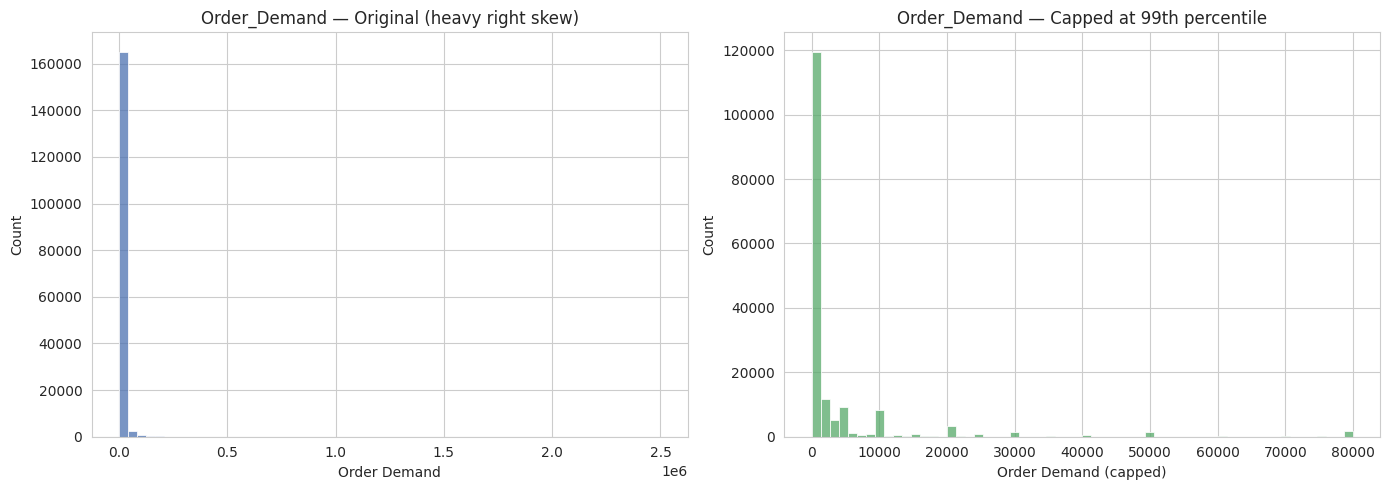

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Order_Demand"], bins=60, ax=axes[0], color="#4C72B0")
axes[0].set_title("Order_Demand — Original (heavy right skew)")
axes[0].set_xlabel("Order Demand")

sns.histplot(df_encoded["Order_Demand_Capped"], bins=60, ax=axes[1], color="#55A868")
axes[1].set_title("Order_Demand — Capped at 99th percentile")
axes[1].set_xlabel("Order Demand (capped)")

plt.tight_layout()
plt.show()


### Demand by Warehouse

/tmp/ipykernel_655/1380104625.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df.assign(Order_Demand_Capped=df_encoded["Order_Demand_Capped"]),


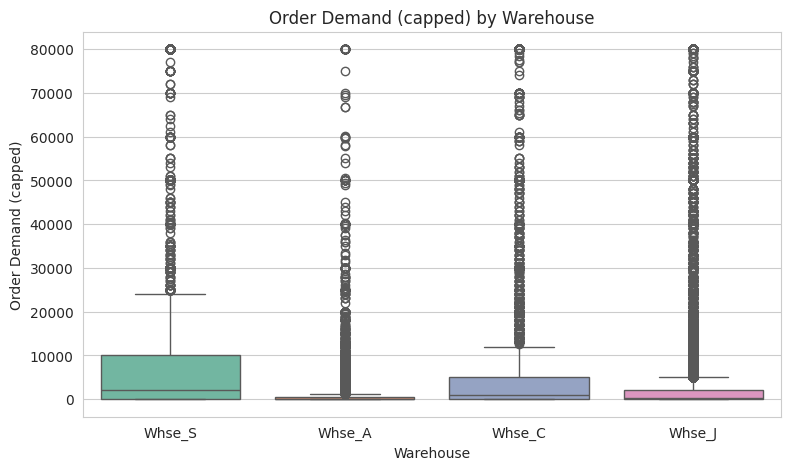

In [17]:
plt.figure(figsize=(9, 5))

# Warehouse was one-hot encoded in df_encoded — use the original df for this categorical view
sns.boxplot(data=df.assign(Order_Demand_Capped=df_encoded["Order_Demand_Capped"]),
            x="Warehouse", y="Order_Demand_Capped", palette="Set2")
plt.title("Order Demand (capped) by Warehouse")
plt.ylabel("Order Demand (capped)")
plt.show()


### Demand by Promotion and Holiday flags

/tmp/ipykernel_655/2818416438.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df.assign(y=df_encoded["Order_Demand_Capped"]), x="Promo", y="y", ax=axes[0], palette="Set1")
/tmp/ipykernel_655/2818416438.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df.assign(y=df_encoded["Order_Demand_Capped"]), x="SchoolHoliday", y="y", ax=axes[1], palette="Set1")
/tmp/ipykernel_655/2818416438.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df.assign(y=df_encoded["Order_Demand_Capped"]), x="StateHoliday", y="y", ax=axes[2], pale

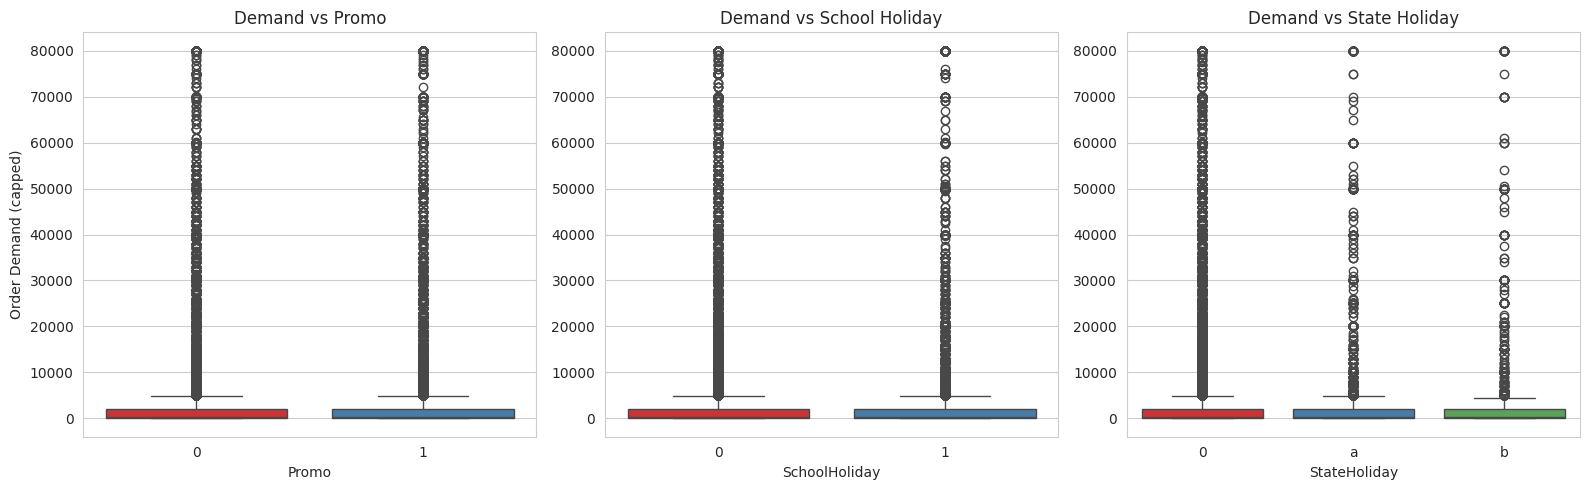

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df.assign(y=df_encoded["Order_Demand_Capped"]), x="Promo", y="y", ax=axes[0], palette="Set1")
axes[0].set_title("Demand vs Promo")
axes[0].set_ylabel("Order Demand (capped)")

sns.boxplot(data=df.assign(y=df_encoded["Order_Demand_Capped"]), x="SchoolHoliday", y="y", ax=axes[1], palette="Set1")
axes[1].set_title("Demand vs School Holiday")
axes[1].set_ylabel("")

sns.boxplot(data=df.assign(y=df_encoded["Order_Demand_Capped"]), x="StateHoliday", y="y", ax=axes[2], palette="Set1")
axes[2].set_title("Demand vs State Holiday")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()


### Demand trend over time

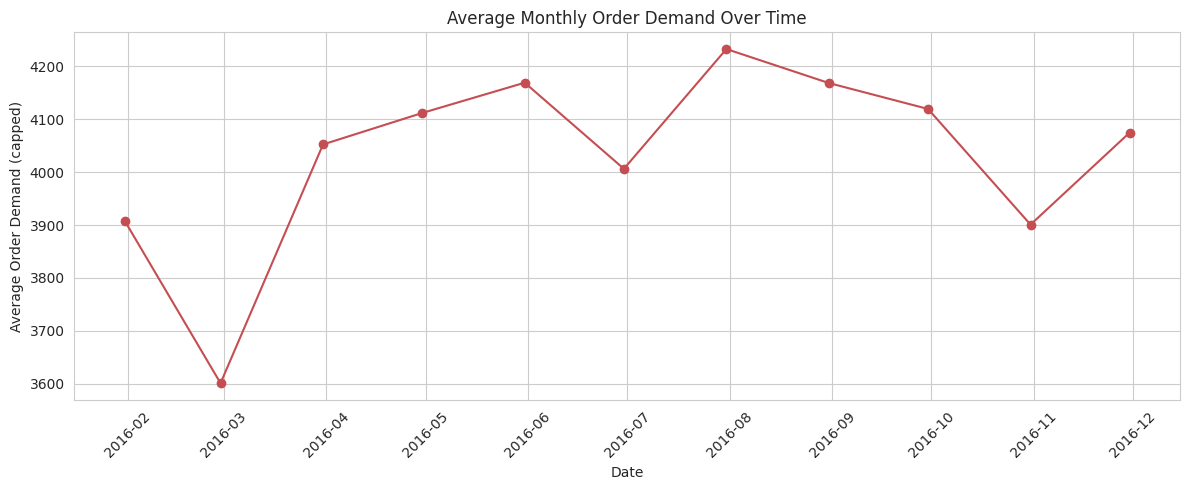

In [19]:
monthly_demand = df.assign(Order_Demand_Capped=df_encoded["Order_Demand_Capped"]).groupby(
    pd.Grouper(key="Date", freq="ME")
)["Order_Demand_Capped"].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(monthly_demand["Date"], monthly_demand["Order_Demand_Capped"], marker="o", color="#C44E52")
plt.title("Average Monthly Order Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Average Order Demand (capped)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Top product categories by average demand

/tmp/ipykernel_655/2171388246.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette="viridis")


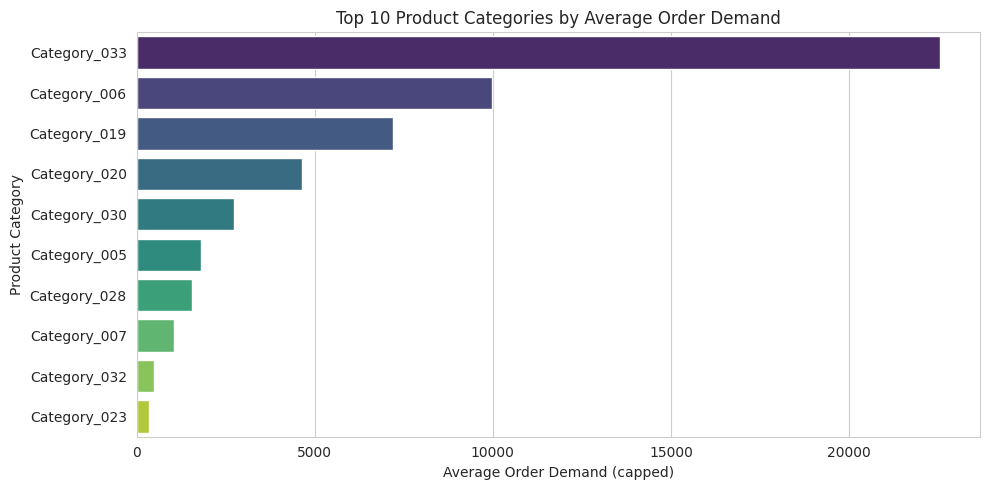

In [20]:
top_categories = df.assign(Order_Demand_Capped=df_encoded["Order_Demand_Capped"]).groupby(
    "Product_Category"
)["Order_Demand_Capped"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_categories.values, y=top_categories.index, palette="viridis")
plt.title("Top 10 Product Categories by Average Order Demand")
plt.xlabel("Average Order Demand (capped)")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()


### Correlation heatmap of numeric features

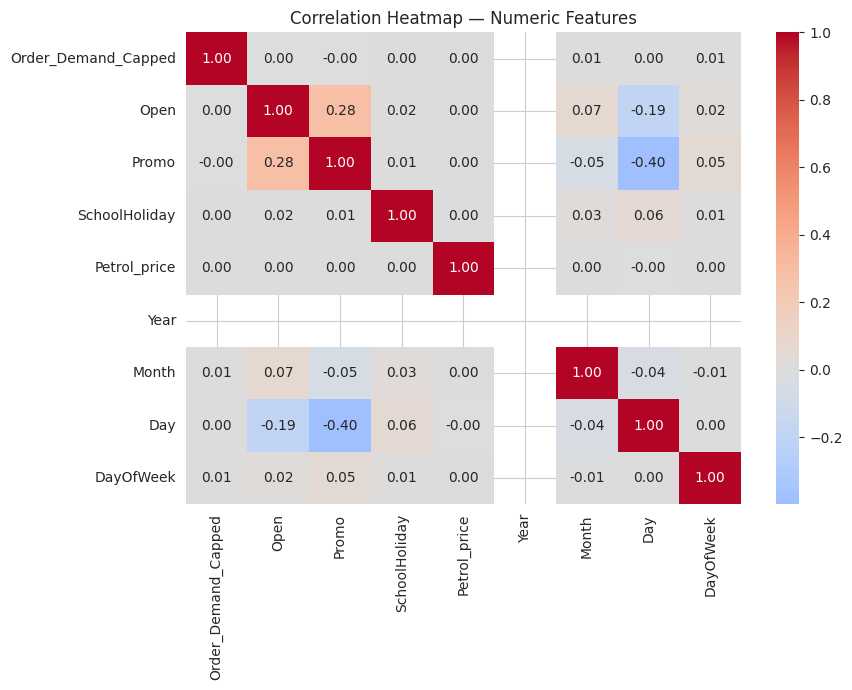

In [21]:
numeric_cols = ["Order_Demand_Capped", "Open", "Promo", "SchoolHoliday",
                 "Petrol_price", "Year", "Month", "Day", "DayOfWeek"]

plt.figure(figsize=(9, 7))
corr = df_encoded[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.show()


### Key EDA observations

- `Order_Demand` is extremely right-skewed with a long tail of bulk orders — the capping step in preprocessing was necessary before this became visible here.
- Demand varies noticeably across **Warehouse** and **Product_Category** — these are likely strong predictors.
- `Promo`, `SchoolHoliday`, and `StateHoliday` show visible shifts in the demand distribution, though the effect looks smaller than warehouse/category differences.
- The correlation heatmap shows **weak linear correlation** between most numeric features and demand individually — this is expected, since categorical features (Warehouse, Product_Category) likely carry more predictive signal than the numeric ones. This is worth keeping in mind for **Step 6 (Feature Engineering)**, where we may need combined or engineered features rather than relying on raw numeric correlation alone.
- No strong multicollinearity is visible among the numeric features shown here — but once Warehouse and Product_Category are one-hot encoded (30+ new columns), the risk of multicollinearity across the *full* feature set increases. This is precisely the scenario Ridge and Lasso are designed to handle.


---
## Feature Engineering & Selection

**What it means:** Build new, more informative features and drop the ones that don't help — this makes the model's job easier.

**In this project:** `Product_id` turns out to be a per-row identifier (169,211 unique values for 169,211 rows — not a stable product ID), so it carries no predictive signal and is dropped. `Product_Code` (2,117 unique products) is too high-cardinality for one-hot encoding, so it will be **target-encoded** using the mean `Order_Demand_Capped` per product — but only after the train/test split (Step 7), fitting the encoding on the training set alone, so information from the validation/test sets never leaks into training. We also engineer two features suggested by the EDA: `Is_Weekend` (from `DayOfWeek`) and a combined `Promo_Or_Holiday` flag, since promotions and holidays showed visible (if modest) shifts in demand.

### Check whether `Product_id` is a stable product identifier

In [22]:
# If Product_id were a real product identifier, each Product_Code should map to
# a small, stable set of Product_id values. Instead:
print("Unique Product_id:", df["Product_id"].nunique(), "out of", len(df), "rows")
print("Max Product_id count per Product_Code:", df.groupby("Product_Code")["Product_id"].nunique().max())

Unique Product_id: 169211 out of 169211 rows
Max Product_id count per Product_Code: 2607


`Product_id` is unique per row — effectively a row/order ID, not a product identifier. It would only let the model memorize individual rows, so we drop it entirely.

### Engineer `Is_Weekend` and `Promo_Or_Holiday`

In [23]:
df_encoded["Is_Weekend"] = (df_encoded["DayOfWeek"] >= 5).astype(int)
df_encoded["Promo_Or_Holiday"] = (
    (df_encoded["Promo"] == 1) |
    (df_encoded["SchoolHoliday"] == 1) |
    (df["StateHoliday"] != "0")
).astype(int)

df_encoded[["DayOfWeek", "Is_Weekend", "Promo", "SchoolHoliday", "Promo_Or_Holiday"]].head()

,DayOfWeek,Is_Weekend,Promo,SchoolHoliday,Promo_Or_Holiday
0,6,1,0,0,0
1,6,1,0,0,0
2,6,1,0,0,0
3,6,1,0,0,0
4,6,1,0,0,0


### Finalize the feature set for modeling

In [24]:
# Drop Product_id (per-row noise, see above), Date (already decomposed into
# Year/Month/Day/DayOfWeek), and the raw Order_Demand (we model the capped version).
# Product_Code is kept for now -- it gets target-encoded in Step 7, after the split.
df_model = df_encoded.drop(columns=["Product_id", "Date", "Order_Demand"])

print("Shape entering Step 7:", df_model.shape)
df_model.head()

Shape entering Step 7: (169211, 47)


,Product_Code,Open,Promo,SchoolHoliday,Petrol_price,Year,Month,Day,DayOfWeek,Order_Demand_Capped,Warehouse_Whse_C,Warehouse_Whse_J,Warehouse_Whse_S,StateHoliday_a,StateHoliday_b,Product_Category_Category_003,Product_Category_Category_005,Product_Category_Category_006,Product_Category_Category_007,Product_Category_Category_008,Product_Category_Category_009,Product_Category_Category_010,Product_Category_Category_011,Product_Category_Category_012,Product_Category_Category_013,Product_Category_Category_014,Product_Category_Category_015,Product_Category_Category_016,Product_Category_Category_017,Product_Category_Category_018,Product_Category_Category_019,Product_Category_Category_020,Product_Category_Category_021,Product_Category_Category_022,Product_Category_Category_023,Product_Category_Category_024,Product_Category_Category_026,Product_Category_Category_027,Product_Category_Category_028,Product_Category_Category_029,Product_Category_Category_030,Product_Category_Category_031,Product_Category_Category_032,Product_Category_Category_033,Petrol_price_scaled,Is_Weekend,Promo_Or_Holiday
0,Product_0033,1,0,0,91,2016,1,3,6,16000.0,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0.613817,1,0
1,Product_1825,1,0,0,85,2016,1,3,6,50000.0,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,-0.608188,1,0
2,Product_0551,1,0,0,85,2016,1,3,6,3000.0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,-0.608188,1,0
3,Product_0556,1,0,0,93,2016,1,3,6,1000.0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,1.021152,1,0
4,Product_1844,1,0,0,95,2016,1,3,6,7.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1.428486,1,0


---
## Train–Validation–Test Split

**What it means:** Divide the dataset so the model learns on one part and is fairly tested on parts it has never seen.

**In this project:** Split 169,211 records 70/15/15 -> ~118,000 for training, ~25,000 for validation (alpha tuning), and ~25,000 held out for the final test. `Product_Code` is target-encoded and all numeric features are scaled **after** this split, fitting on the training set only, so the validation and test sets stay genuinely unseen.

In [25]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df_model, test_size=0.30, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)

print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)

Train: (118447, 47)
Val:   (25382, 47)
Test:  (25382, 47)


### Target-encode `Product_Code` (fit on train only)

In [26]:
global_mean = train_df["Order_Demand_Capped"].mean()
code_means = train_df.groupby("Product_Code")["Order_Demand_Capped"].mean()

# Unseen Product_Codes in val/test (products that happened to land only in
# the other splits) fall back to the global training mean.
for split_df in (train_df, val_df, test_df):
    split_df["Product_Code_TargetEnc"] = split_df["Product_Code"].map(code_means).fillna(global_mean)

train_df = train_df.drop(columns=["Product_Code"])
val_df   = val_df.drop(columns=["Product_Code"])
test_df  = test_df.drop(columns=["Product_Code"])

train_df[["Product_Code_TargetEnc"]].describe()

,Product_Code_TargetEnc
count,118447.000000
mean,4010.744704
std,6628.754614
min,1.000000
25%,51.186813
50%,857.692308
75%,4848.450057
max,60147.058824


### Scale numeric features (fit on train only)

Previously only `Petrol_price` was scaled. Ridge and Lasso penalize coefficient *magnitude*, so every numeric feature needs to be on a comparable scale, or unscaled features (like `Year`, which ranges in the thousands) get penalized unfairly relative to already-scaled ones. We scale `Year`, `Month`, `Day`, `DayOfWeek`, `Petrol_price`, and the new `Product_Code_TargetEnc` together, fitting `StandardScaler` on the training set and applying it to validation/test.

In [27]:
from sklearn.preprocessing import StandardScaler

numeric_to_scale = ["Year", "Month", "Day", "DayOfWeek", "Petrol_price", "Product_Code_TargetEnc"]

scaler = StandardScaler()
train_df[numeric_to_scale] = scaler.fit_transform(train_df[numeric_to_scale])
val_df[numeric_to_scale]   = scaler.transform(val_df[numeric_to_scale])
test_df[numeric_to_scale]  = scaler.transform(test_df[numeric_to_scale])

train_df[numeric_to_scale].describe()

,Year,Month,Day,DayOfWeek,Petrol_price,Product_Code_TargetEnc
count,118447.0,1.184470e+05,1.184470e+05,1.184470e+05,1.184470e+05,1.184470e+05
mean,0.0,1.455315e-16,-6.004823e-17,1.217761e-17,-3.634088e-16,-2.153578e-17
std,0.0,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00
min,0.0,-1.576206e+00,-1.649517e+00,-1.375746e+00,-1.628691e+00,-6.049042e-01
25%,0.0,-9.355400e-01,-8.505469e-01,-6.805987e-01,-8.144597e-01,-5.973331e-01
50%,0.0,2.545963e-02,-5.157709e-02,1.454888e-02,-2.285679e-04,-4.756649e-01
75%,0.0,9.864593e-01,8.615313e-01,7.096964e-01,8.140025e-01,1.263750e-01
max,0.0,1.627126e+00,1.774640e+00,2.795139e+00,1.628234e+00,8.468642e+00


### Separate features (X) and target (y)

In [28]:
y_train = train_df.pop("Order_Demand_Capped")
y_val   = val_df.pop("Order_Demand_Capped")
y_test  = test_df.pop("Order_Demand_Capped")

X_train = train_df.astype(float)
X_val   = val_df.astype(float)
X_test  = test_df.astype(float)

print("X_train:", X_train.shape, " X_val:", X_val.shape, " X_test:", X_test.shape)

X_train: (118447, 46)  X_val: (25382, 46)  X_test: (25382, 46)


---
## Model Selection

**What it means:** Shortlist a few candidate algorithms that suit the type of problem, before committing to one.

**In this project:** This is a regression problem, and the project brief specifically asks us to compare **Ridge (L2)** and **Lasso (L1)** regression, since one-hot encoding `Warehouse` and `Product_Category` introduces multicollinearity that ordinary linear regression handles poorly. We also fit a plain **Linear Regression (OLS)** as an unregularized baseline, so the value Ridge/Lasso add is measurable rather than assumed.

---
## Model Training

**What it means:** Fit each candidate model on the training data and tune its hyperparameters for the best performance.

**In this project:** We tune each model's regularization strength (`alpha`) using 5-fold cross-validation via `RidgeCV`/`LassoCV`, searching 20 candidate values spaced logarithmically from 0.001 to 1000, since the right order of magnitude for alpha isn't known in advance.

In [29]:
import numpy as np
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV

alphas = np.logspace(-3, 3, 20)

ols = LinearRegression().fit(X_train, y_train)

ridge = RidgeCV(alphas=alphas, cv=5).fit(X_train, y_train)
print("Best Ridge alpha:", ridge.alpha_)

lasso = LassoCV(alphas=alphas, cv=5, max_iter=5000, n_jobs=-1).fit(X_train, y_train)
print("Best Lasso alpha:", lasso.alpha_)

Best Ridge alpha: 26.366508987303554
Best Lasso alpha: 0.3359818286283781


---
## Model Evaluation

**What it means:** Score every model on the same held-out metrics so the comparison between them is fair.

**In this project:** We evaluate OLS, Ridge, and Lasso on the **validation set** (never touched during training or alpha tuning) using MAE, MSE, RMSE, and R², as specified in the project abstract.

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(name, y_true, y_pred, results):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    results.append({"Model": name, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2})
    return results

results = []
evaluate("OLS (baseline)", y_val, ols.predict(X_val), results)
evaluate("Ridge",          y_val, ridge.predict(X_val), results)
evaluate("Lasso",          y_val, lasso.predict(X_val), results)

results_df = pd.DataFrame(results).set_index("Model").round(3)
results_df

,MAE,MSE,RMSE,R2
Model,,,,
OLS (baseline),3820.110,8.646249e+07,9298.521,0.333
Ridge,3819.298,8.645874e+07,9298.319,0.333
Lasso,3818.716,8.645957e+07,9298.364,0.333


### Visual comparison of validation RMSE and R²

/tmp/ipykernel_655/3347993933.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df["RMSE"], ax=axes[0], palette="Set2")
/tmp/ipykernel_655/3347993933.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df["R2"], ax=axes[1], palette="Set2")


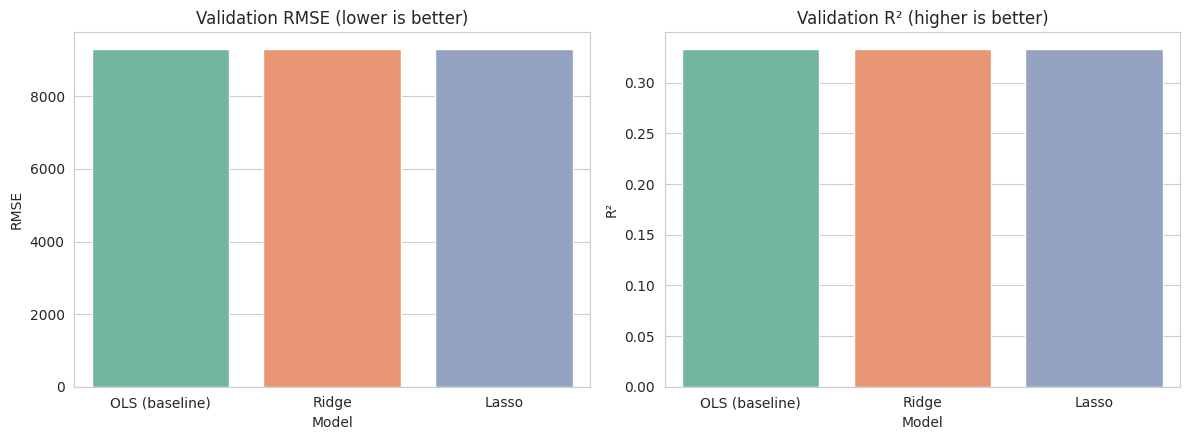

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.barplot(x=results_df.index, y=results_df["RMSE"], ax=axes[0], palette="Set2")
axes[0].set_title("Validation RMSE (lower is better)")
axes[0].set_ylabel("RMSE")

sns.barplot(x=results_df.index, y=results_df["R2"], ax=axes[1], palette="Set2")
axes[1].set_title("Validation R² (higher is better)")
axes[1].set_ylabel("R²")

plt.tight_layout()
plt.show()

---
## Final Model & Interpretation

**What it means:** Pick the best-performing model and explain why it makes the predictions it does.

**In this project:** Ridge, Lasso, and OLS perform almost identically on validation R²/RMSE here, which tells us the regularization isn't fighting severe overfitting on this dataset size -- but Lasso is still the more useful model for this project's goal, because it automatically zeroes out the least informative one-hot columns, directly answering *which* factors drive demand. We report Lasso's coefficients and confirm the chosen model's performance on the untouched **test set**.

Lasso zeroed out 14 of 46 features


/tmp/ipykernel_655/1322473645.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_coefs.values, y=top_coefs.index, palette="coolwarm")


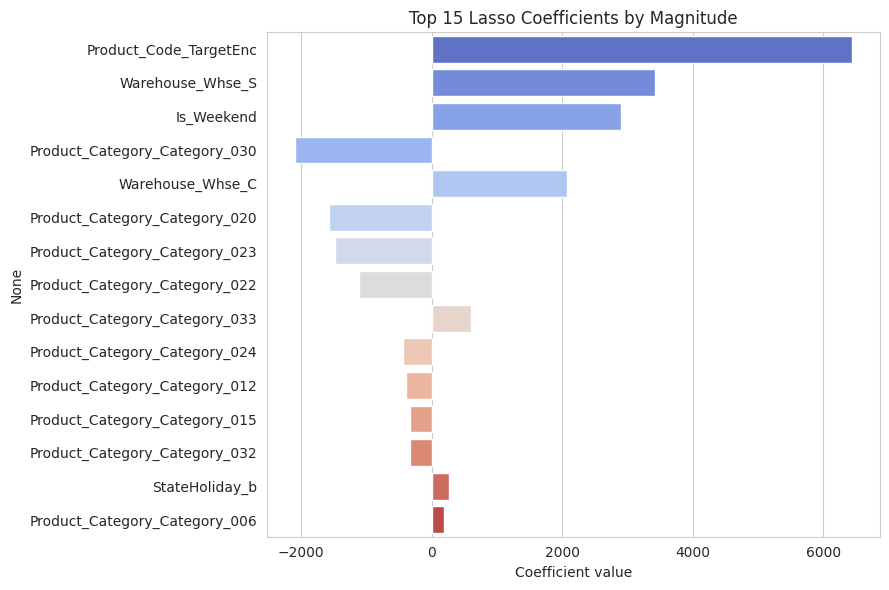

In [32]:
coef_series = pd.Series(lasso.coef_, index=X_train.columns)
n_zeroed = (coef_series == 0).sum()
print(f"Lasso zeroed out {n_zeroed} of {len(coef_series)} features")

top_coefs = coef_series.reindex(coef_series.abs().sort_values(ascending=False).index).head(15)
plt.figure(figsize=(9, 6))
sns.barplot(x=top_coefs.values, y=top_coefs.index, palette="coolwarm")
plt.title("Top 15 Lasso Coefficients by Magnitude")
plt.xlabel("Coefficient value")
plt.tight_layout()
plt.show()

### Final performance on the held-out test set

In [33]:
test_results = []
evaluate("Lasso (test)", y_test, lasso.predict(X_test), test_results)
pd.DataFrame(test_results).set_index("Model").round(3)

,MAE,MSE,RMSE,R2
Model,,,,
Lasso (test),3816.421,8.680605e+07,9316.977,0.327


**Interpretation:** `Product_Code_TargetEnc` carries by far the strongest signal (unsurprising -- it directly encodes each product's historical average demand), followed by `Warehouse` and select `Product_Category` dummies, echoing the EDA. `Promo`, `SchoolHoliday`, and the engineered `Is_Weekend`/`Promo_Or_Holiday` features contribute smaller but non-zero effects. Lasso's feature selection confirms the EDA's finding that a handful of categorical features drive most of the demand signal, while several one-hot columns (mainly low-frequency product categories) add little and are safely dropped -- exactly the scenario Lasso is designed for.